# Building a Basic Feed Forward Neural Network Classifier in Keras
Neural networks are a fundamental part of deep learning. In this lesson, we will learn how to build a basic feed forward neural network classifier using Keras, a popular deep learning library in Python.


## Group Discussion Question
Why are neural networks considered powerful tools for classification tasks? 

How do the layers and neurons in a neural network contribute to its ability to learn complex patterns? 

Discuss with your group and provide examples of real-world applications where neural networks have been successfully applied.


## Example: Building a Feed Forward Neural Network Classifier
We will use the Keras library to build a simple feed forward neural network classifier. We will use the popular Iris dataset for this example.

### Step 1: Importing Libraries and Dataset
We will start by importing the necessary libraries and loading the dataset.

In [5]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert labels to categorical one-hot encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

### Step 2: Building the Neural Network
We will define a simple feed forward neural network with an input layer, one hidden layer, and an output layer.

In [6]:
# Initialize the model
model = Sequential()

# Add input layer and hidden layer
model.add(Dense(10, input_shape=(X_train.shape[1],), activation='relu'))

# Add output layer
model.add(Dense(y_train.shape[1], activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

c:\Users\enson\OneDrive\Desktop\NewBeginnings\.venv\Lib\site-packages\keras\src\layers\core\dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83 (332.00 B)

 Trainable params: 83 (332.00 B)

 Non-trainable params: 0 (0.00 B)

### Step 3: Training the Neural Network
We will train the neural network using the training data.

In [7]:
# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=5, validation_data=(X_test, y_test), verbose=1)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4103 - loss: 1.1372 - val_accuracy: 0.5333 - val_loss: 1.0143
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4624 - loss: 1.1076 - val_accuracy: 0.5333 - val_loss: 0.9465
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4481 - loss: 1.0240 - val_accuracy: 0.5333 - val_loss: 0.8896
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4702 - loss: 0.9703 - val_accuracy: 0.6000 - val_loss: 0.8380
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4913 - loss: 0.9446 - val_accuracy: 0.6333 - val_loss: 0.7924
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6588 - loss: 0.8789 - val_accuracy: 0.7000 - val_loss: 0.7500
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6532 - loss: 0.7930 - val_accuracy: 0.7000 - val_loss: 0.7114
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7228 - loss: 0.7457 - val_accuracy: 0.7000 - val_loss

### Step 4: Evaluating the Neural Network
We will evaluate the neural network using the testing data and plot the training history.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.9333 - loss: 0.1722
Test Loss: 0.1721552163362503
Test Accuracy: 0.9333333373069763


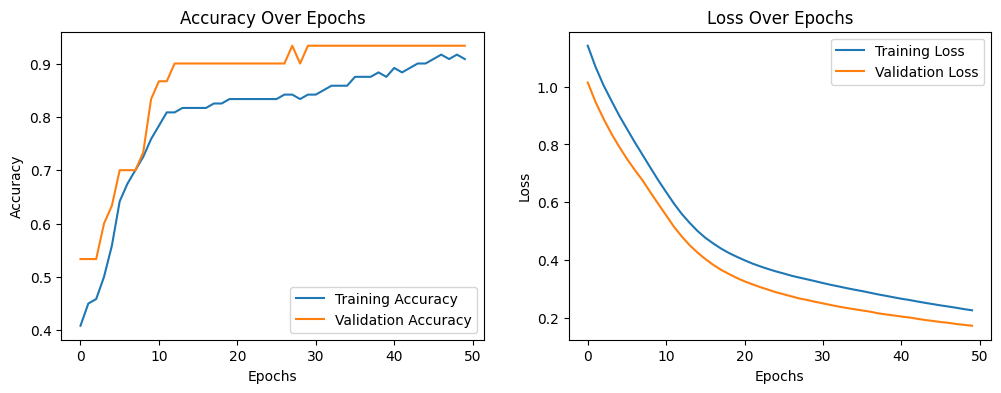

In [8]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy}')

# Plot training history
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Over Epochs')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Over Epochs')

plt.show()

## Practice Problems
1. Modify the neural network to include an additional hidden layer. Train and evaluate the model and compare the performance with the original model.

2. Experiment with different activation functions (e.g., sigmoid, tanh) for the hidden layer. Train and evaluate the model to see how the choice of activation function affects performance.


## Extensions

### Regularization Techniques
Explore how regularization techniques like dropout and L2 regularization can be applied to the neural network to prevent overfitting.

### Optimizers
Experiment with different optimizers (e.g., SGD, RMSprop) and compare their impact on the model's performance.

### Hyperparameter Tuning
Use hyperparameter tuning techniques such as grid search or random search to find the best set of hyperparameters for the neural network.


# Conclusion
Building a feed forward neural network classifier using Keras is straightforward and powerful for classification tasks. By understanding the basics of neural network architecture, activation functions, and model training, you can create and evaluate your own models. 

Experimenting with different configurations and techniques can further enhance the performance of your neural networks.
